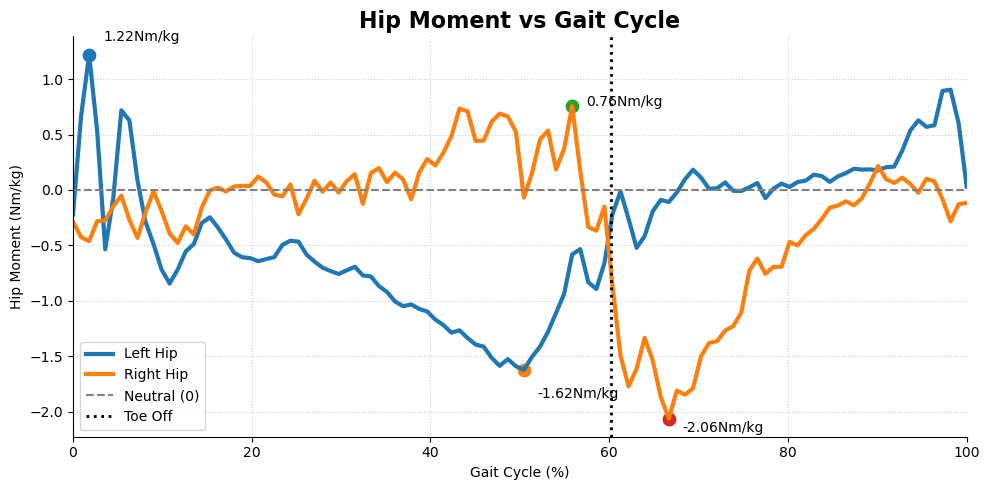

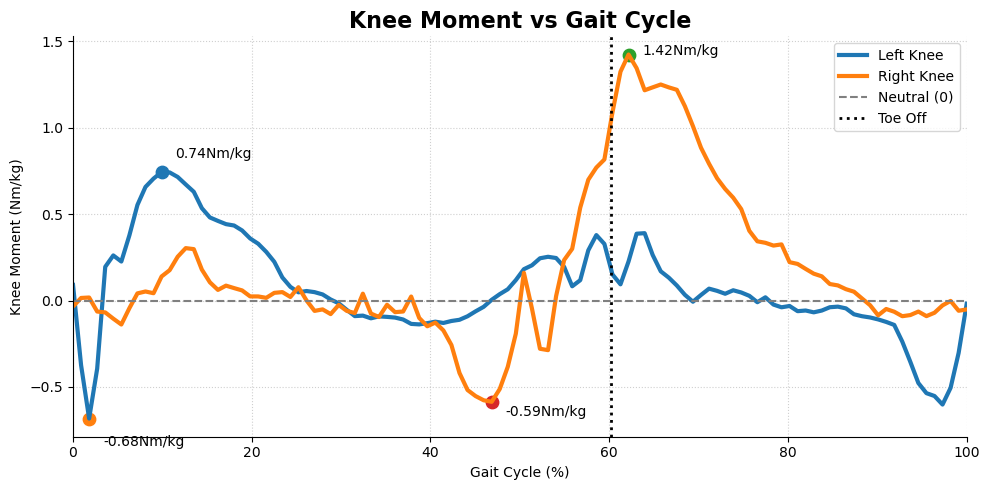

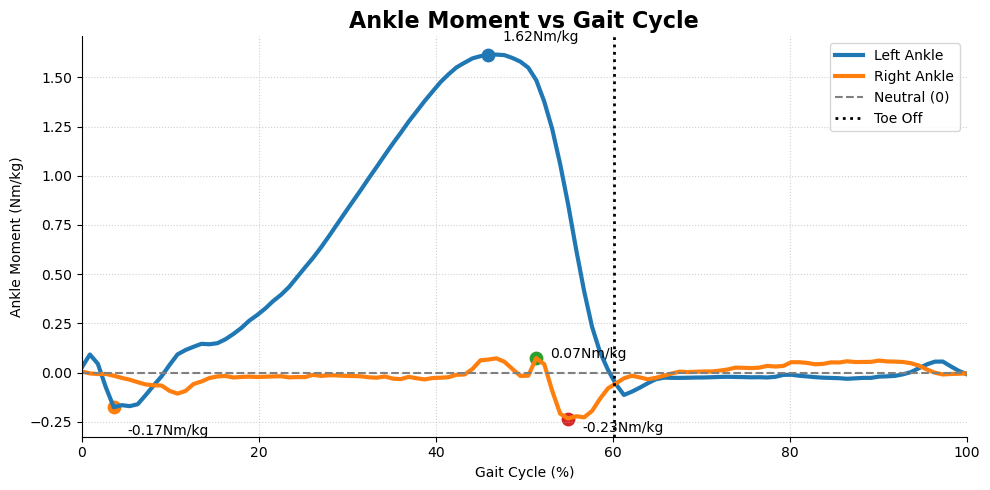


Hip
------------------------------
Left Max : 1.22Nm/kg
Left Min : -1.62Nm/kg
Right Max: 0.76Nm/kg
Right Min: -2.06Nm/kg

Knee
------------------------------
Left Max : 0.74Nm/kg
Left Min : -0.68Nm/kg
Right Max: 1.42Nm/kg
Right Min: -0.59Nm/kg

Ankle
------------------------------
Left Max : 1.62Nm/kg
Left Min : -0.17Nm/kg
Right Max: 0.07Nm/kg
Right Min: -0.23Nm/kg


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Metadata

metadata = {
    "frame_number": 114,
    "first_frame": 336,
    "point_frequency": 100,
    "analog_frequency": 100,
    "bw": 78
}

events = {
    "LHS_start": 3.35,
    "LHS_end": 4.48,
    "RHS": 3.91,
    "LTO": 4.03,
}

# Read Excel

df = pd.read_excel(
    "Walk_002.xlsx",
    header=None
)

# Extract Data

time = pd.to_numeric(
    df.iloc[125:237, 0],
    errors="coerce"
).reset_index(drop=True)

LHIP_moment = pd.to_numeric(df.iloc[8:120, 82], errors="coerce").reset_index(drop=True)/1000
LKNEE_moment = pd.to_numeric(df.iloc[8:120, 76], errors="coerce").reset_index(drop=True)/1000
LANKLE_moment = pd.to_numeric(df.iloc[8:120, 67], errors="coerce").reset_index(drop=True)/1000

RHIP_moment = pd.to_numeric(df.iloc[8:120, 79], errors="coerce").reset_index(drop=True)/1000
RKNEE_moment = pd.to_numeric(df.iloc[8:120, 73], errors="coerce").reset_index(drop=True)/1000
RANKLE_moment = pd.to_numeric(df.iloc[8:120, 70], errors="coerce").reset_index(drop=True)/1000

# Time Normalisation

time_norm = (
    (time - time.iloc[0])
    /
    (time.iloc[-1] - time.iloc[0])
) * 100

# Toe-Off Position

toe_off = (
    (events["LTO"] - events["LHS_start"])
    /
    (events["LHS_end"] - events["LHS_start"])
) * 100

# Plot Function

def plot_moment(time_norm, left, right, joint_name):

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        time_norm,
        left,
        linewidth=3,
        label=f"Left {joint_name}"
    )

    ax.plot(
        time_norm,
        right,
        linewidth=3,
        label=f"Right {joint_name}"
    )

    # Neutral line
    ax.axhline(
        0,
        linestyle="--",
        color="grey",
        linewidth=1.5,
        label="Neutral (0)"
    )

    # Toe-off
    ax.axvline(
        toe_off,
        linestyle=":",
        color="black",
        linewidth=2,
        label="Toe Off"
    )

    # Left max/min markers
    ax.scatter(
        time_norm.iloc[left.idxmax()],
        left.max(),
        s=80
    )

    ax.scatter(
        time_norm.iloc[left.idxmin()],
        left.min(),
        s=80
    )

    # Right max/min markers
    ax.scatter(
        time_norm.iloc[right.idxmax()],
        right.max(),
        s=80
    )

    ax.scatter(
        time_norm.iloc[right.idxmin()],
        right.min(),
        s=80
    )

    ax.annotate(
    f"{left.max():.2f}Nm/kg",
    (
        time_norm.iloc[left.idxmax()],
        left.max()
    ),
    xytext=(10,10),
    textcoords="offset points"
)
    
    ax.annotate(
    f"{left.min():.2f}Nm/kg",
    (
        time_norm.iloc[left.idxmin()],
        left.min()
    ),
    xytext=(10,-20),
    textcoords="offset points"
)
    
    ax.annotate(
    f"{right.max():.2f}Nm/kg",
    (
        time_norm.iloc[right.idxmax()],
        right.max()
    ),
    xytext=(10,0),
    textcoords="offset points"
)
    
    ax.annotate(
    f"{right.min():.2f}Nm/kg",
    (
        time_norm.iloc[right.idxmin()],
        right.min()
    ),
    xytext=(10,-10),
    textcoords="offset points"
)

    ax.set_title(
        f"{joint_name} Moment vs Gait Cycle",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Gait Cycle (%)"
    )

    ax.set_ylabel(
        f"{joint_name} Moment (Nm/kg)"
    )

    ax.set_xlim(0, 100)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        True,
        linestyle=":",
        alpha=0.6
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

# Max-Min Function

def print_max_min(left, right, joint_name):

    print(f"\n{joint_name}")
    print("-" * 30)

    print(f"Left Max : {left.max():.2f}Nm/kg")
    print(f"Left Min : {left.min():.2f}Nm/kg")

    print(f"Right Max: {right.max():.2f}Nm/kg")
    print(f"Right Min: {right.min():.2f}Nm/kg")

# Generate Graphs

plot_moment(
    time_norm,
    LHIP_moment,
    RHIP_moment,
    "Hip"
)

plot_moment(
    time_norm,
    LKNEE_moment,
    RKNEE_moment,
    "Knee"
)

plot_moment(
    time_norm,
    LANKLE_moment,
    RANKLE_moment,
    "Ankle"
)

# Print Metrics

print_max_min(
    LHIP_moment,
    RHIP_moment,
    "Hip"
)

print_max_min(
    LKNEE_moment,
    RKNEE_moment,
    "Knee"
)

print_max_min(
    LANKLE_moment,
    RANKLE_moment,
    "Ankle"
)